In [1]:
# =========================================================
# TRAFFIC DEMAND PREDICTION - COMPLETE EDA
# Google Colab Notebook
# =========================================================

# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# ==========================================
# 1. MOUNT GOOGLE DRIVE
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ==========================================
# 2. LOAD DATA FROM GOOGLE DRIVE
# ==========================================

import pandas as pd

# CHANGE THIS PATH ACCORDING TO YOUR DRIVE FOLDER

train_path = '/content/drive/MyDrive/Traffic_Prediction/dataset/train.csv'
test_path = '/content/drive/MyDrive/Traffic_Prediction/dataset/test.csv'

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("Train Shape :", train.shape)
print("Test Shape  :", test.shape)

Train Shape : (77299, 11)
Test Shape  : (41778, 10)


In [5]:
# =========================
# 3. FIRST LOOK AT DATA
# =========================

train.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [6]:
# =========================
# 4. BASIC INFORMATION
# =========================

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


In [7]:
# =========================
# 5. CHECK DATATYPES
# =========================

train.dtypes

,0
Index,int64
geohash,object
day,int64
timestamp,object
demand,float64
RoadType,object
NumberofLanes,int64
LargeVehicles,object
Landmarks,object
Temperature,float64


In [8]:
# =========================
# 6. STATISTICAL SUMMARY
# =========================

train.describe(include='all')

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
count,77299.000000,77299,77299.000000,77299,7.729900e+04,76699,77299.000000,77299,77299,74804.000000,76502
unique,NaN,1249,NaN,96,NaN,3,NaN,2,2,NaN,4
top,NaN,qp03wd,NaN,2:0,NaN,Residential,NaN,Not Allowed,Yes,NaN,Sunny
freq,NaN,105,NaN,1778,NaN,69230,NaN,50673,52042,NaN,27717
mean,38649.000000,NaN,48.101838,NaN,9.394238e-02,NaN,2.014334,NaN,NaN,16.405354,NaN
std,22314.443566,NaN,0.302438,NaN,1.421905e-01,NaN,0.904665,NaN,NaN,7.359835,NaN
min,0.000000,NaN,48.000000,NaN,6.245650e-07,NaN,1.000000,NaN,NaN,-14.935097,NaN
25%,19324.500000,NaN,48.000000,NaN,1.822723e-02,NaN,1.000000,NaN,NaN,11.430473,NaN
50%,38649.000000,NaN,48.000000,NaN,4.775994e-02,NaN,2.000000,NaN,NaN,16.382587,NaN
75%,57973.500000,NaN,48.000000,NaN,1.085951e-01,NaN,3.000000,NaN,NaN,21.298833,NaN


In [9]:
# =========================
# 7. CHECK MISSING VALUES
# =========================

missing_values = train.isnull().sum()

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Values': missing_values.values,
    'Percentage': (missing_values.values / len(train)) * 100
})

missing_df = missing_df.sort_values(by='Missing Values', ascending=False)

missing_df

,Column,Missing Values,Percentage
9,Temperature,2495,3.227726
10,Weather,797,1.031061
5,RoadType,600,0.776207
2,day,0,0.000000
1,geohash,0,0.000000
0,Index,0,0.000000
3,timestamp,0,0.000000
6,NumberofLanes,0,0.000000
4,demand,0,0.000000
8,Landmarks,0,0.000000


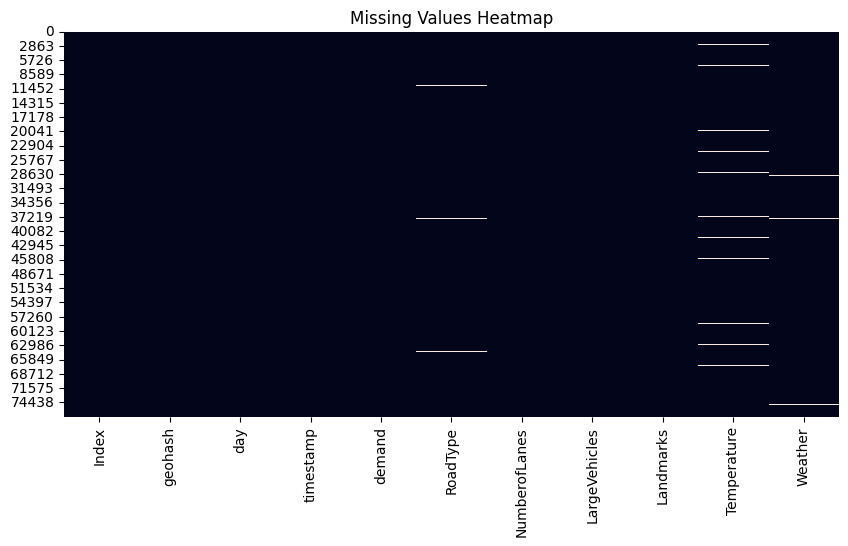

In [10]:
# =========================
# 8. VISUALIZE MISSING VALUES
# =========================

plt.figure(figsize=(10,5))

sns.heatmap(train.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.show()

In [11]:
# =========================
# 9. DUPLICATE ROWS
# =========================

duplicates = train.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


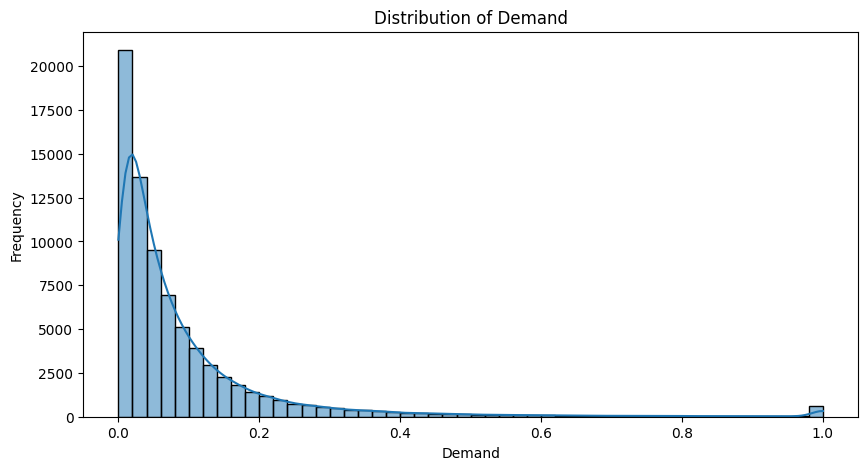

In [12]:
# =========================
# 10. TARGET VARIABLE ANALYSIS
# =========================

plt.figure(figsize=(10,5))

sns.histplot(train['demand'], bins=50, kde=True)

plt.title("Distribution of Demand")
plt.xlabel("Demand")
plt.ylabel("Frequency")

plt.show()

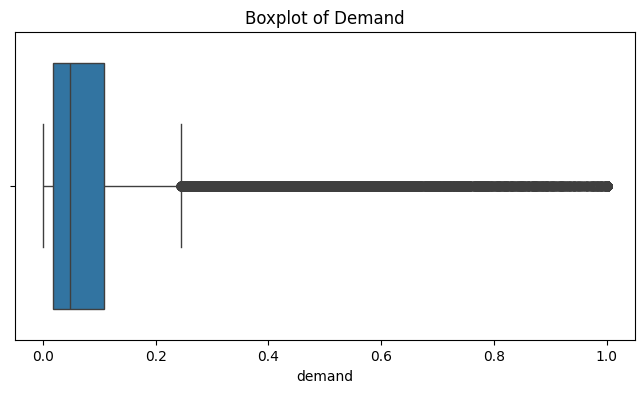

In [13]:
# =========================
# 11. TARGET VARIABLE BOXPLOT
# =========================

plt.figure(figsize=(8,4))

sns.boxplot(x=train['demand'])

plt.title("Boxplot of Demand")

plt.show()

In [15]:
# =========================
# 12. NUMERICAL COLUMNS
# =========================

numerical_cols = train.select_dtypes(include=np.number).columns.tolist()

print("Numerical Columns:")
print(numerical_cols)

Numerical Columns:
['Index', 'day', 'demand', 'NumberofLanes', 'Temperature']


In [16]:
# =========================
# 13. CATEGORICAL COLUMNS
# =========================

categorical_cols = train.select_dtypes(include='object').columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
['geohash', 'timestamp', 'RoadType', 'LargeVehicles', 'Landmarks', 'Weather']


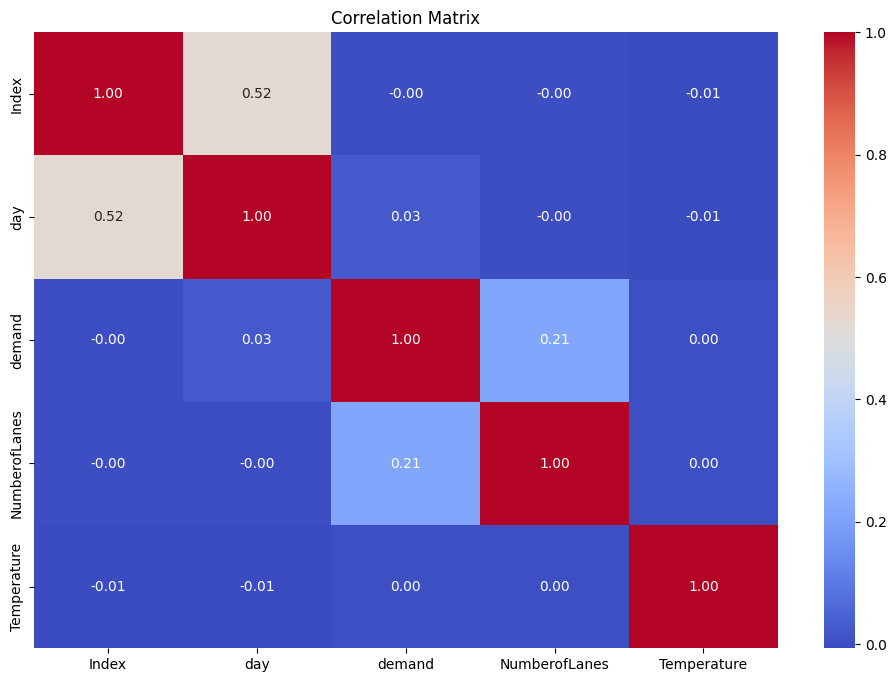

In [17]:
# =========================
# 14. CORRELATION MATRIX
# =========================

plt.figure(figsize=(12,8))

corr = train.corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Matrix")

plt.show()

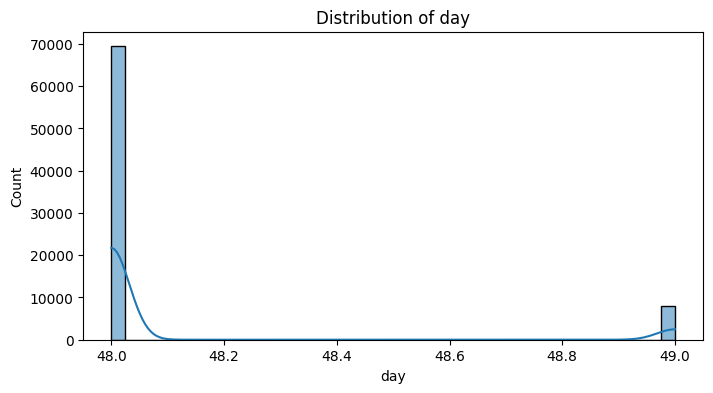

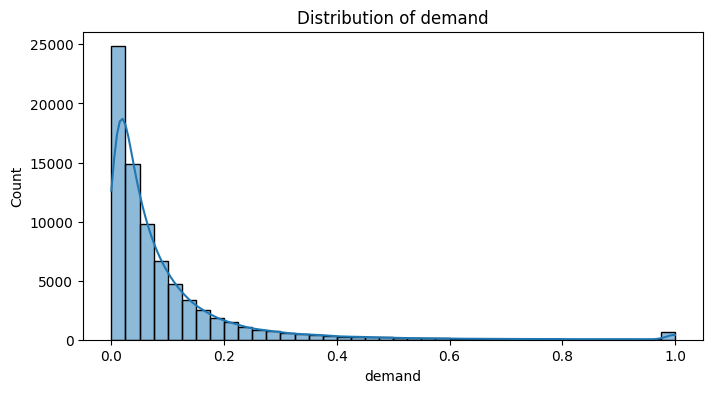

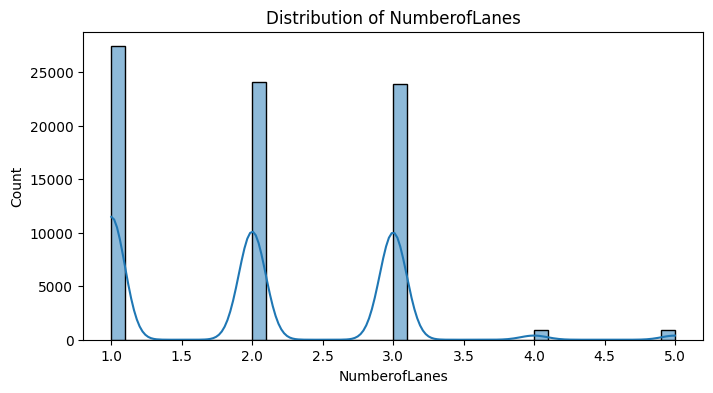

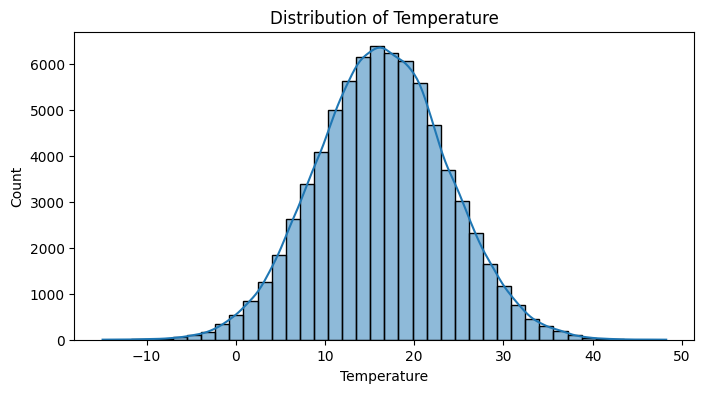

In [18]:
# =========================
# 15. DISTRIBUTION OF NUMERICAL FEATURES
# =========================

for col in numerical_cols:

    if col != 'Index':

        plt.figure(figsize=(8,4))

        sns.histplot(train[col], kde=True, bins=40)

        plt.title(f"Distribution of {col}")

        plt.show()

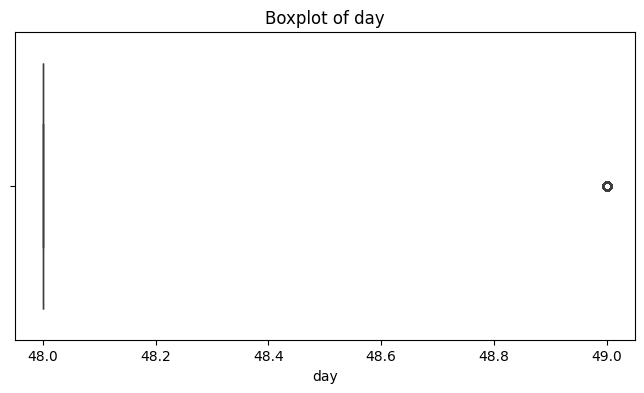

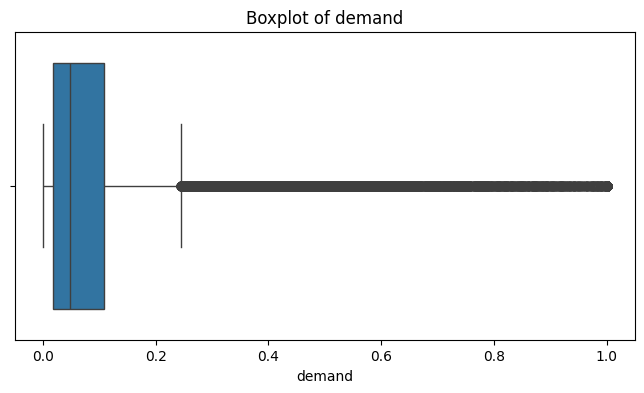

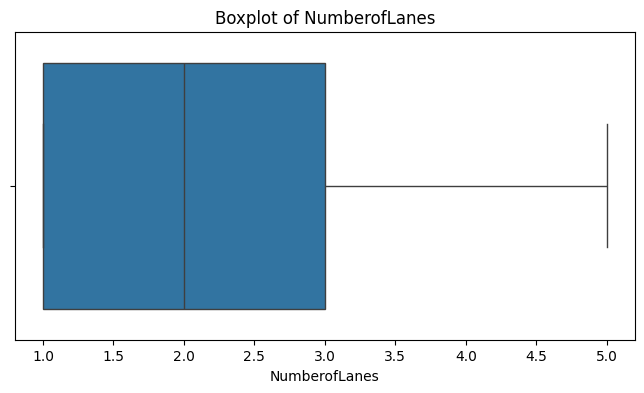

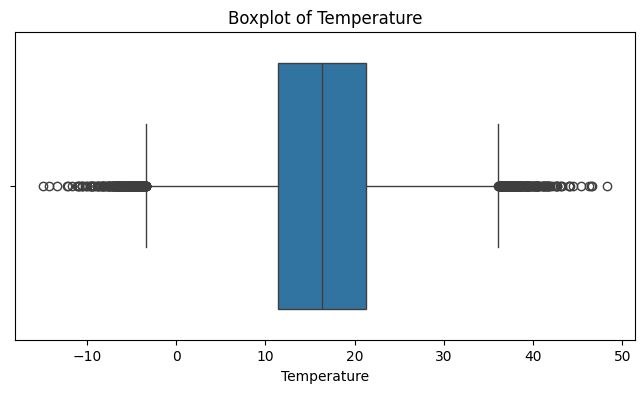

In [19]:
# =========================
# 16. BOXPLOTS FOR NUMERICAL FEATURES
# =========================

for col in numerical_cols:

    if col != 'Index':

        plt.figure(figsize=(8,4))

        sns.boxplot(x=train[col])

        plt.title(f"Boxplot of {col}")

        plt.show()

In [20]:
# =========================
# 17. UNIQUE VALUES IN CATEGORICAL FEATURES
# =========================

for col in categorical_cols:

    print("="*50)
    print(f"{col}")
    print("="*50)

    print("Unique Values :", train[col].nunique())

    print(train[col].value_counts())

    print("\n")

geohash
Unique Values : 1249
geohash
qp03wd    105
qp03wf    105
qp09t0    105
qp03w9    105
qp03x3    105
         ... 
qp08gs      1
qp08fq      1
qp0d1t      1
qp09vc      1
qp09jc      1
Name: count, Length: 1249, dtype: int64


timestamp
Unique Values : 96
timestamp
2:0      1778
1:45     1755
1:30     1750
1:15     1698
1:0      1668
0:30     1617
0:45     1609
0:15     1578
0:0      1534
6:0       928
4:45      925
4:30      923
4:0       921
10:45     920
6:30      917
6:15      917
4:15      914
3:45      914
5:45      913
5:0       911
7:0       909
10:30     907
6:45      903
3:30      903
11:0      902
9:45      902
5:15      902
10:0      899
11:45     898
10:15     896
5:30      895
2:15      895
2:30      895
8:45      895
3:15      894
9:0       893
12:15     893
11:30     891
7:45      890
7:30      889
2:45      887
12:0      887
9:30      886
3:0       884
7:15      881
12:30     880
8:15      878
8:30      876
11:15     876
9:15      868
12:45     865
13:0      861


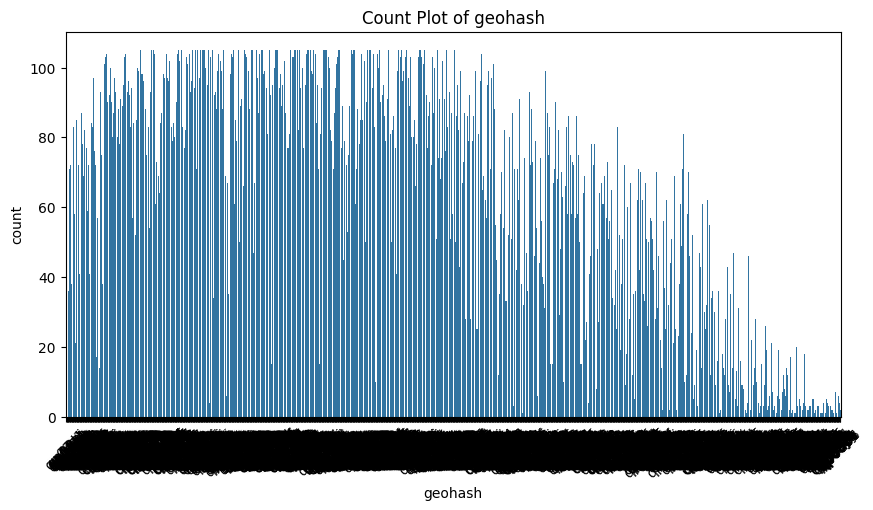

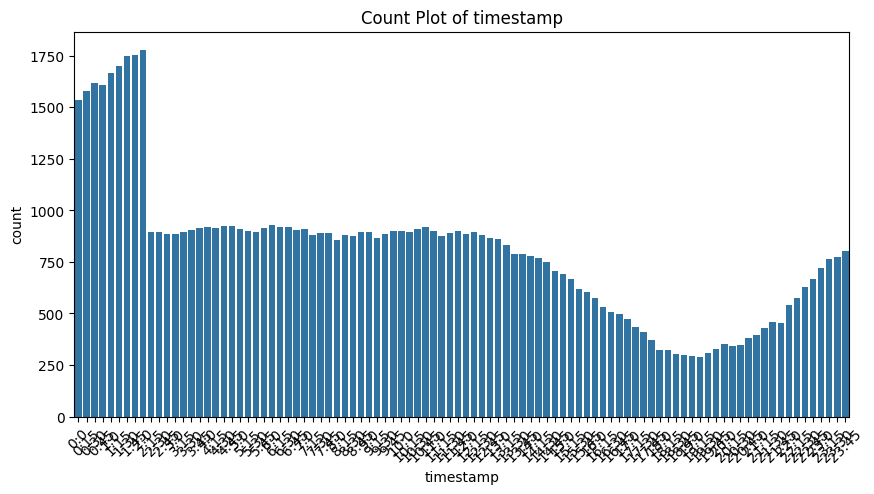

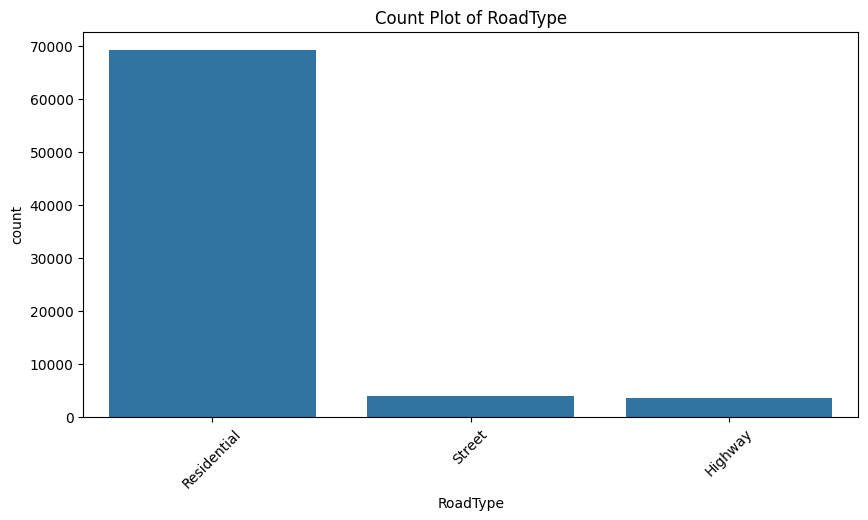

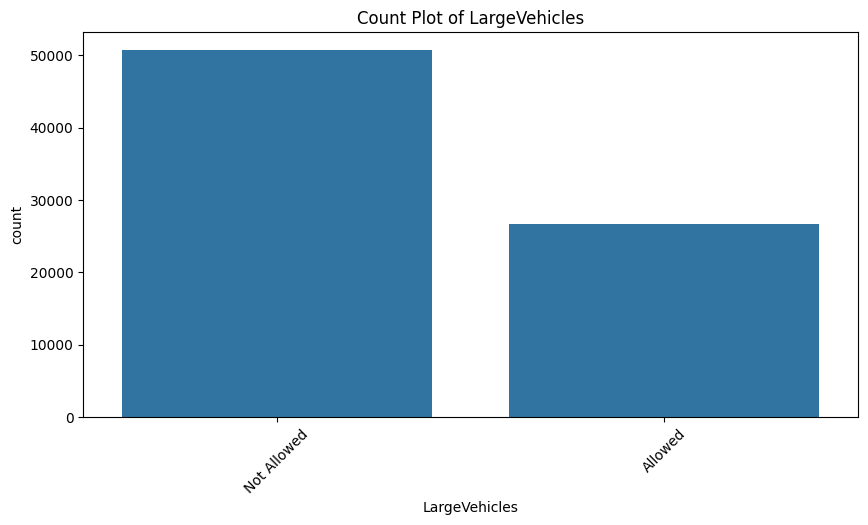

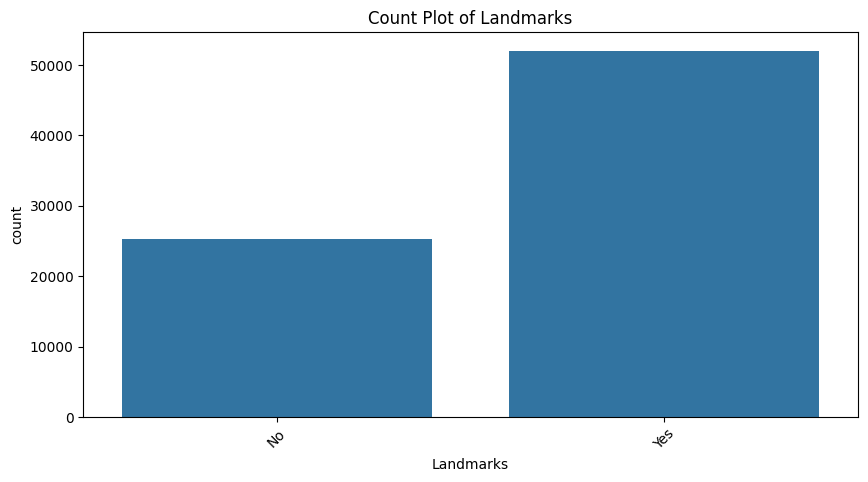

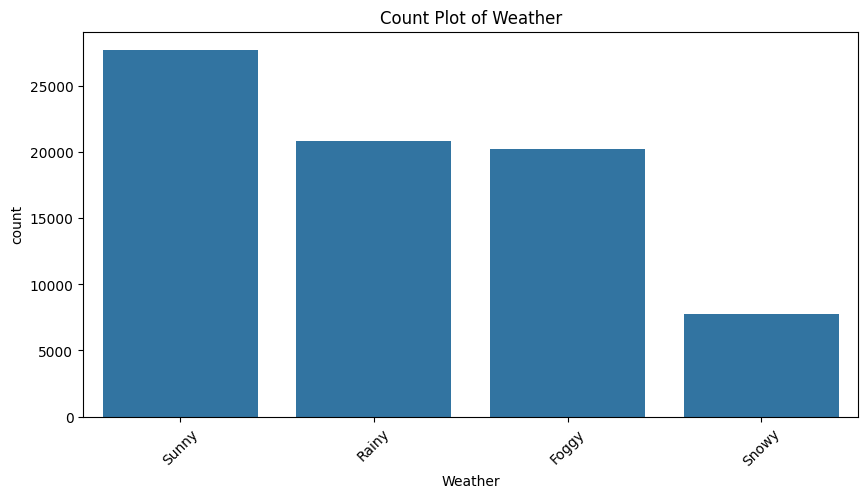

In [21]:
# =========================
# 18. COUNT PLOTS FOR CATEGORICAL FEATURES
# =========================

for col in categorical_cols:

    plt.figure(figsize=(10,5))

    sns.countplot(x=train[col])

    plt.title(f"Count Plot of {col}")

    plt.xticks(rotation=45)

    plt.show()

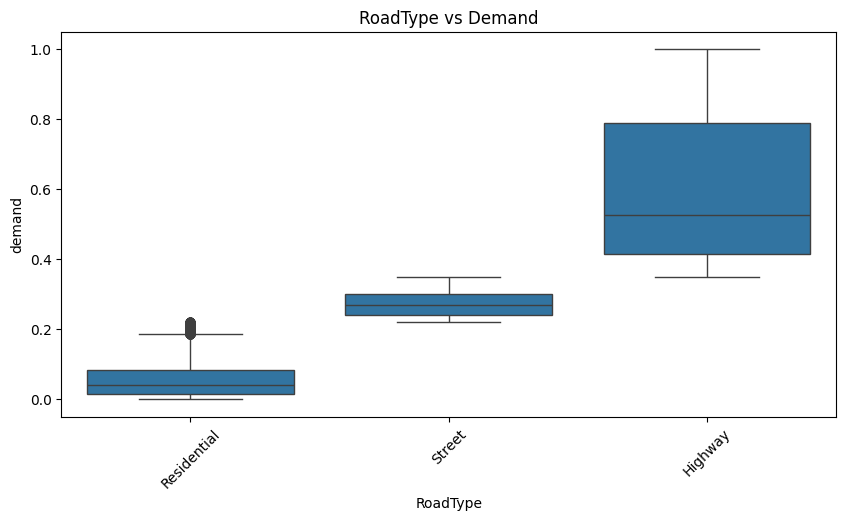

In [22]:
# =========================
# 19. ROAD TYPE VS DEMAND
# =========================

plt.figure(figsize=(10,5))

sns.boxplot(x='RoadType',
            y='demand',
            data=train)

plt.title("RoadType vs Demand")

plt.xticks(rotation=45)

plt.show()

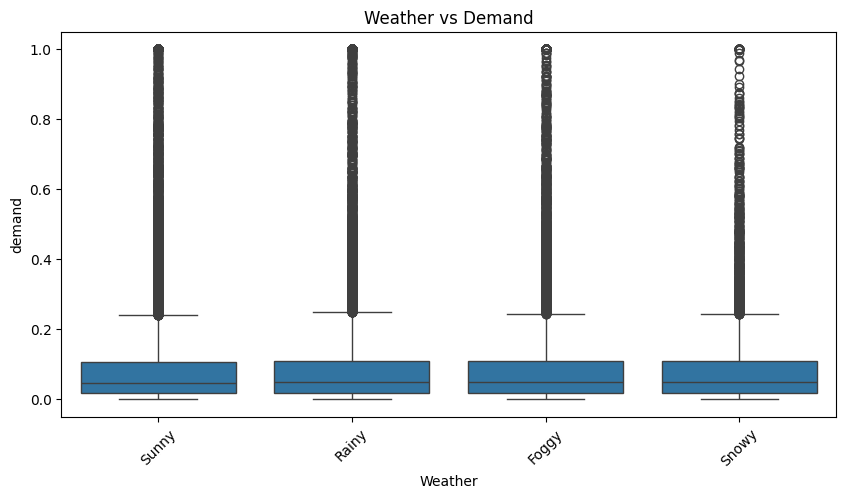

In [23]:
# =========================
# 20. WEATHER VS DEMAND
# =========================

plt.figure(figsize=(10,5))

sns.boxplot(x='Weather',
            y='demand',
            data=train)

plt.title("Weather vs Demand")

plt.xticks(rotation=45)

plt.show()

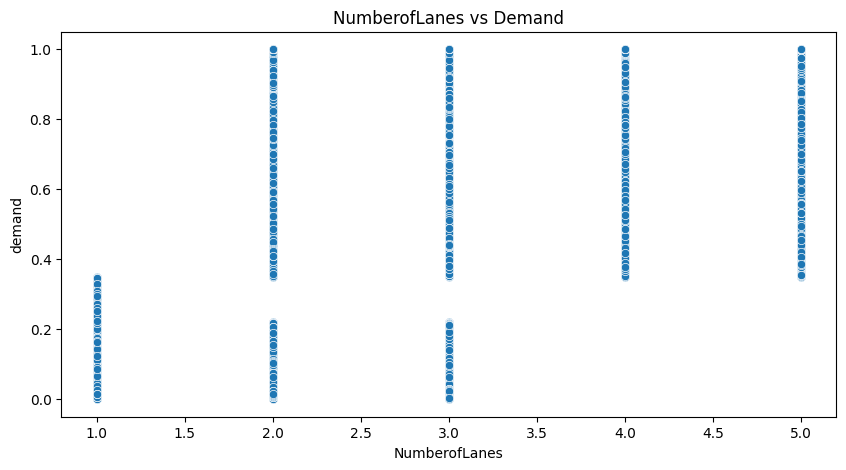

In [24]:
# =========================
# 21. LANES VS DEMAND
# =========================

plt.figure(figsize=(10,5))

sns.scatterplot(x='NumberofLanes',
                y='demand',
                data=train)

plt.title("NumberofLanes vs Demand")

plt.show()

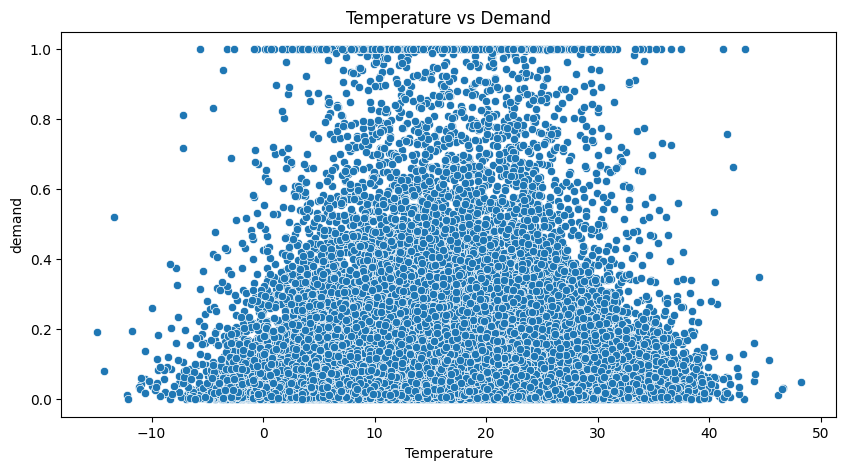

In [25]:
# =========================
# 22. TEMPERATURE VS DEMAND
# =========================

plt.figure(figsize=(10,5))

sns.scatterplot(x='Temperature',
                y='demand',
                data=train)

plt.title("Temperature vs Demand")

plt.show()

In [27]:
import pandas as pd

# =========================
# 23. TIMESTAMP FEATURE ENGINEERING
# =========================

train['timestamp'] = pd.to_datetime('2000-01-01 ' + train['timestamp'])

train['hour'] = train['timestamp'].dt.hour
train['minute'] = train['timestamp'].dt.minute
train['dayofweek'] = train['timestamp'].dt.dayofweek
train['month'] = train['timestamp'].dt.month

train[['timestamp','hour','minute','dayofweek','month']].head()

,timestamp,hour,minute,dayofweek,month
0,2000-01-01,0,0,5,1
1,2000-01-01,0,0,5,1
2,2000-01-01,0,0,5,1
3,2000-01-01,0,0,5,1
4,2000-01-01,0,0,5,1


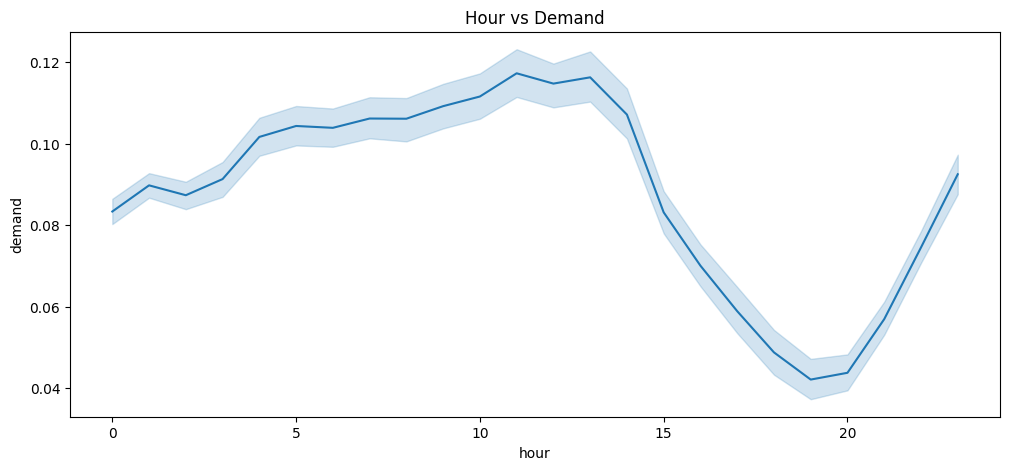

In [28]:
# =========================
# 24. HOUR VS DEMAND
# =========================

plt.figure(figsize=(12,5))

sns.lineplot(x='hour',
             y='demand',
             data=train)

plt.title("Hour vs Demand")

plt.show()

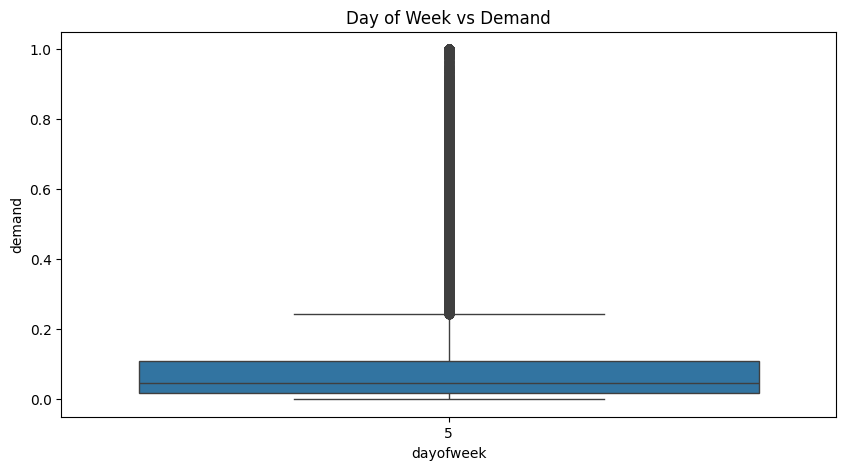

In [29]:
# =========================
# 25. DAY OF WEEK VS DEMAND
# =========================

plt.figure(figsize=(10,5))

sns.boxplot(x='dayofweek',
            y='demand',
            data=train)

plt.title("Day of Week vs Demand")

plt.show()

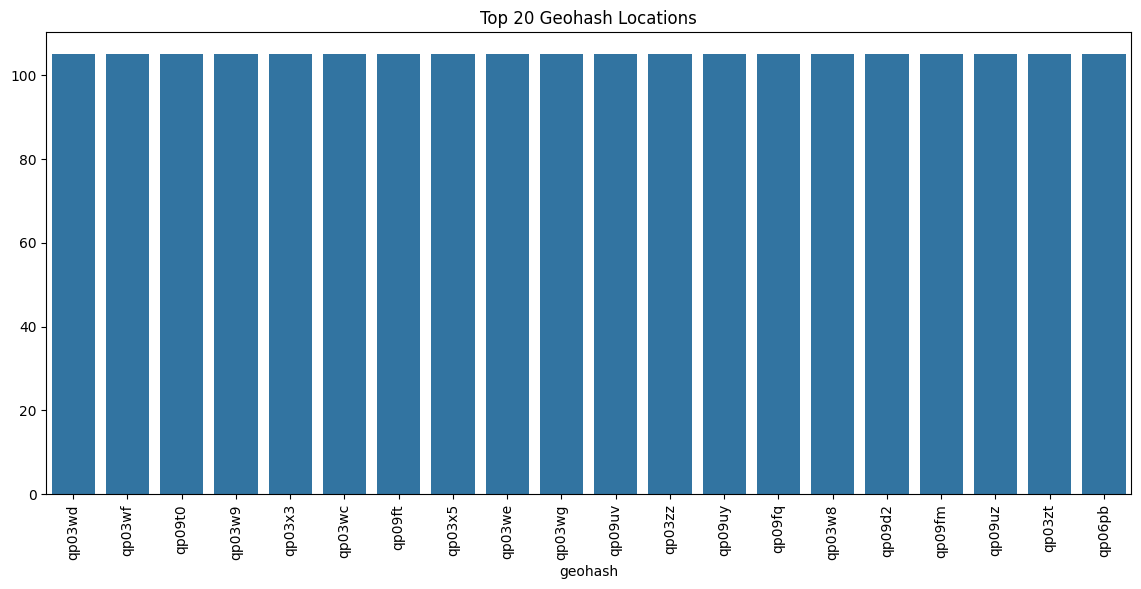

In [30]:
# =========================
# 26. TOP GEOHASH LOCATIONS
# =========================

top_geohash = train['geohash'].value_counts().head(20)

plt.figure(figsize=(14,6))

sns.barplot(x=top_geohash.index,
            y=top_geohash.values)

plt.title("Top 20 Geohash Locations")

plt.xticks(rotation=90)

plt.show()

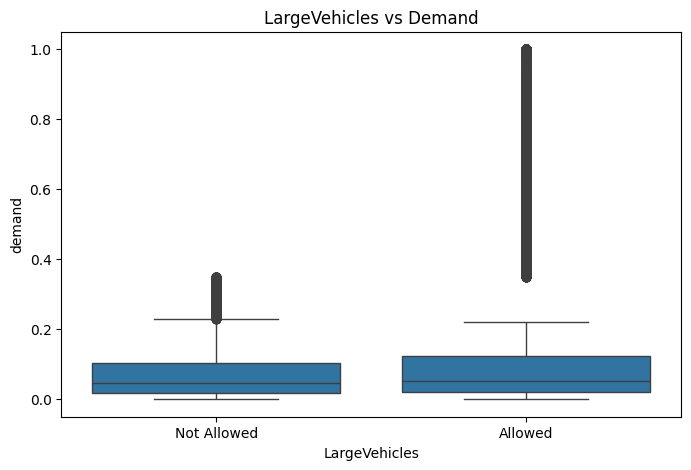

In [31]:
# =========================
# 27. DEMAND BY LARGE VEHICLES
# =========================

plt.figure(figsize=(8,5))

sns.boxplot(x='LargeVehicles',
            y='demand',
            data=train)

plt.title("LargeVehicles vs Demand")

plt.show()

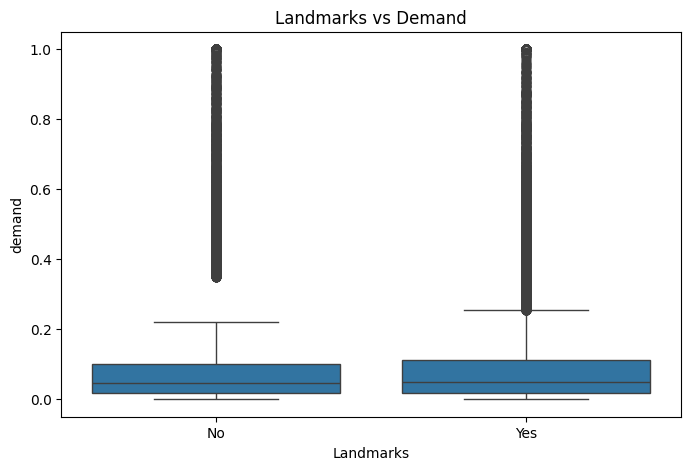

In [32]:
# =========================
# 28. DEMAND BY LANDMARKS
# =========================

plt.figure(figsize=(8,5))

sns.boxplot(x='Landmarks',
            y='demand',
            data=train)

plt.title("Landmarks vs Demand")

plt.show()

In [33]:
# =========================
# 29. CHECK SKEWNESS
# =========================

skewness = train[numerical_cols].skew()

print(skewness.sort_values(ascending=False))

demand           3.728517
day              2.633086
NumberofLanes    0.453042
Temperature      0.021596
Index            0.000000
dtype: float64
